In [ ]:
PROJECT NAME: Wine Quality Prediction (LEVEL2,TASK2)
NAME: AMULA BLESSING PERESUWODE
CATEGORY: DATA ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\DELL\Desktop\task 6\WineQT.csv"
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1143, 13)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

Missing Values:
fixed acidity        

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
print(df["quality"].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


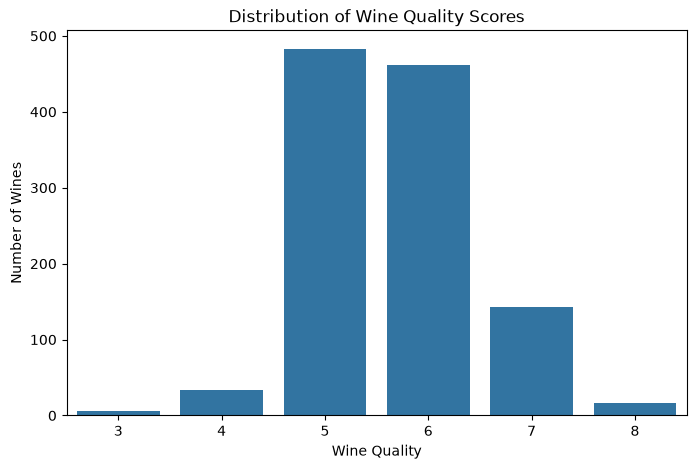

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.show()


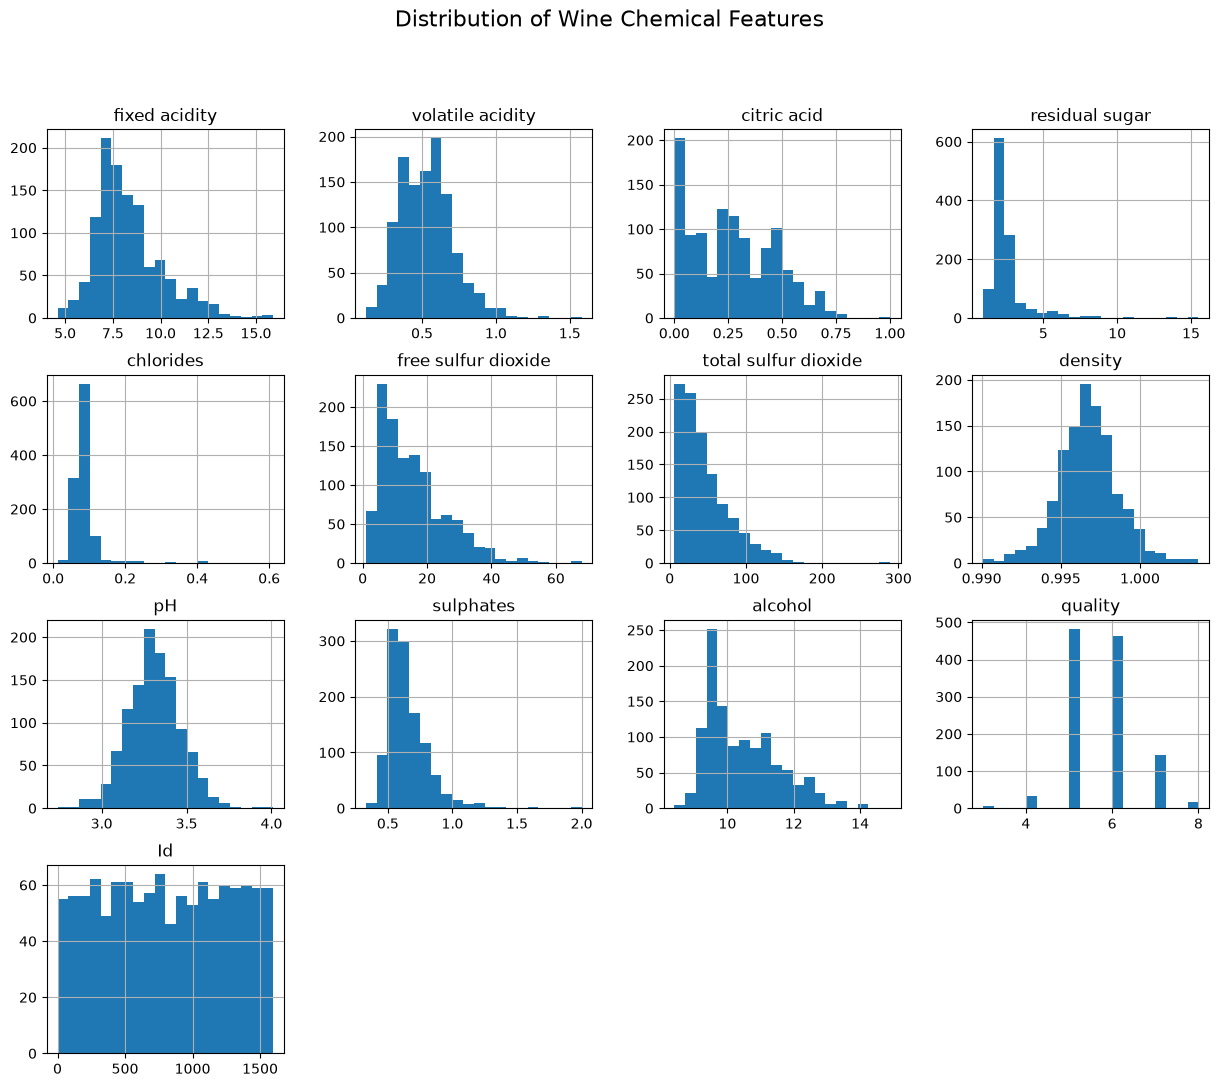

In [7]:
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Wine Chemical Features", fontsize=16)

plt.show()

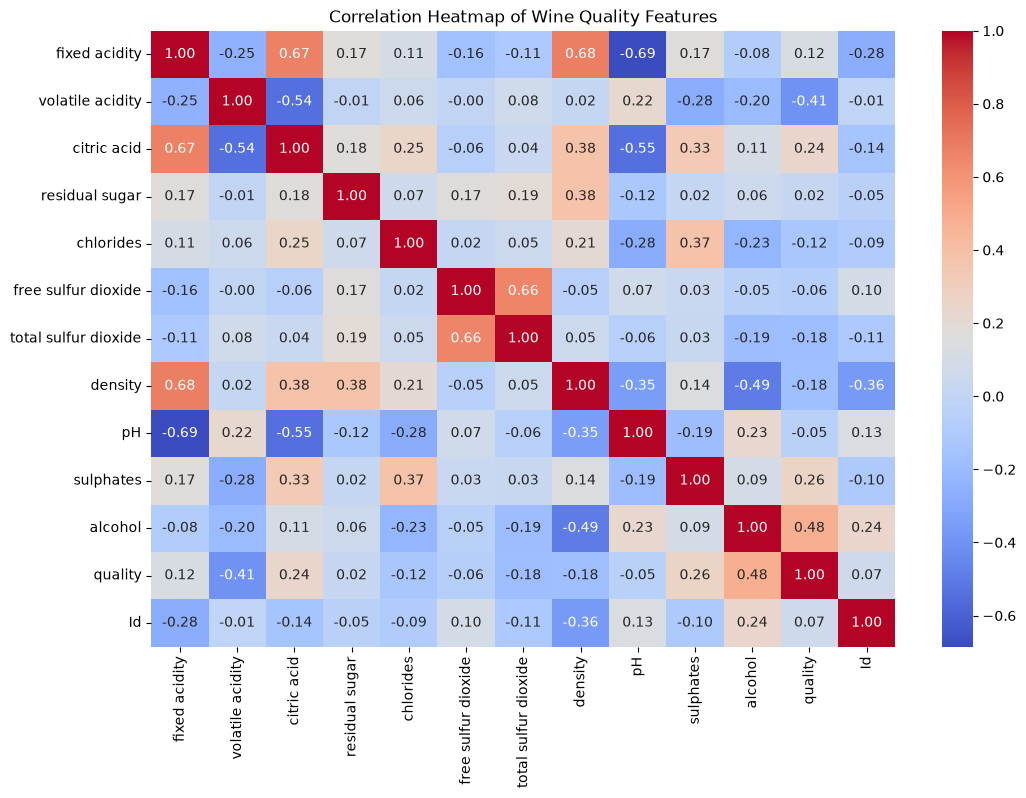

In [8]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Wine Quality Features")

plt.show()

In [3]:
quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [4]:
quality_percent = df["quality"].value_counts(normalize=True).sort_index() * 100

print(quality_percent.round(2))

quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: proportion, dtype: float64


In [5]:
def quality_group(quality):
    if quality <= 5:
        return "Low"
    elif quality == 6:
        return "Medium"
    else:
        return "High"

df["quality_group"] = df["quality"].apply(quality_group)

df[["quality", "quality_group"]].head(10)

,quality,quality_group
0,5,Low
1,5,Low
2,5,Low
3,6,Medium
4,5,Low
5,5,Low
6,5,Low
7,7,High
8,7,High
9,5,Low


In [6]:
print(df["quality_group"].value_counts())

quality_group
Low       522
Medium    462
High      159
Name: count, dtype: int64


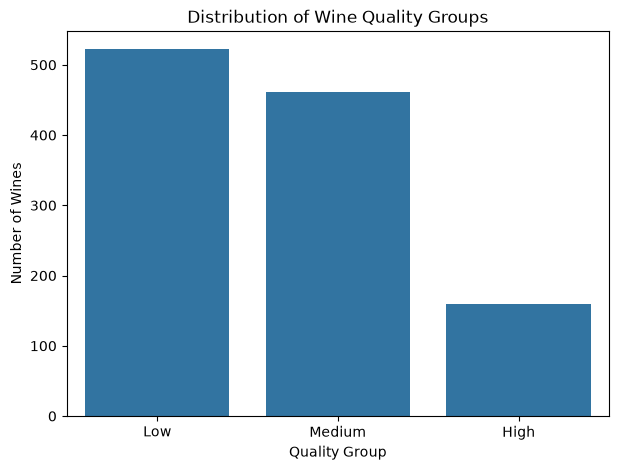

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="quality_group")

plt.title("Distribution of Wine Quality Groups")
plt.xlabel("Quality Group")
plt.ylabel("Number of Wines")

plt.show()

## Class Imbalance Discussion

The distribution of wine quality scores is not balanced across all classes. Some quality levels contain significantly more wine samples than others, while the lower and higher quality levels are less represented.

Class imbalance can affect classification models because a model may become biased toward the majority class and perform poorly when predicting minority classes. Therefore, accuracy alone may not give a complete picture of model performance.

To address this issue, the original quality scores were grouped into three categories: **Low, Medium, and High**. This reduces the number of classes and makes the classification problem more manageable while still preserving meaningful differences in wine quality.


In [9]:
X = df.drop(columns=["quality", "quality_group"])
y = df["quality_group"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1143, 12)
Target shape: (1143,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (914, 12)
Testing features: (229, 12)
Training target: (914,)
Testing target: (229,)


In [11]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training class distribution:
quality_group
Low       0.456
Medium    0.405
High      0.139
Name: proportion, dtype: float64

Testing class distribution:
quality_group
Low       0.459
Medium    0.402
High      0.140
Name: proportion, dtype: float64


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [14]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sgd_model = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        random_state=42,
        max_iter=1000,
        tol=1e-3
    )
)

sgd_model.fit(X_train, y_train)

sgd_pred = sgd_model.predict(X_test)

print("SGD Classifier trained successfully!")

SGD Classifier trained successfully!


In [15]:
from sklearn.svm import SVC

svc_model = make_pipeline(
    StandardScaler(),
    SVC()
)

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

print("SVC model trained successfully!")

SVC model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)
sgd_accuracy = accuracy_score(y_test, sgd_pred)
svc_accuracy = accuracy_score(y_test, svc_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("SGD Accuracy:", sgd_accuracy)
print("SVC Accuracy:", svc_accuracy)

Random Forest Accuracy: 0.6724890829694323
SGD Accuracy: 0.5720524017467249
SVC Accuracy: 0.6462882096069869


In [17]:
from sklearn.metrics import classification_report

print("RANDOM FOREST CLASSIFICATION REPORT")
print(classification_report(y_test, rf_pred))

print("\nSGD CLASSIFICATION REPORT")
print(classification_report(y_test, sgd_pred))

print("\nSVC CLASSIFICATION REPORT")
print(classification_report(y_test, svc_pred))

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.77      0.62      0.69        32
         Low       0.72      0.71      0.72       105
      Medium       0.60      0.64      0.62        92

    accuracy                           0.67       229
   macro avg       0.70      0.66      0.68       229
weighted avg       0.68      0.67      0.67       229


SGD CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.43      0.41      0.42        32
         Low       0.69      0.65      0.67       105
      Medium       0.50      0.54      0.52        92

    accuracy                           0.57       229
   macro avg       0.54      0.53      0.54       229
weighted avg       0.58      0.57      0.57       229


SVC CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.59      0.31      0.41        32
         Low       0.74      0.74      

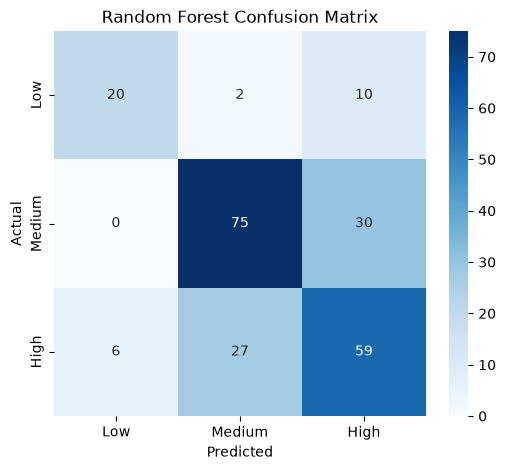

In [18]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

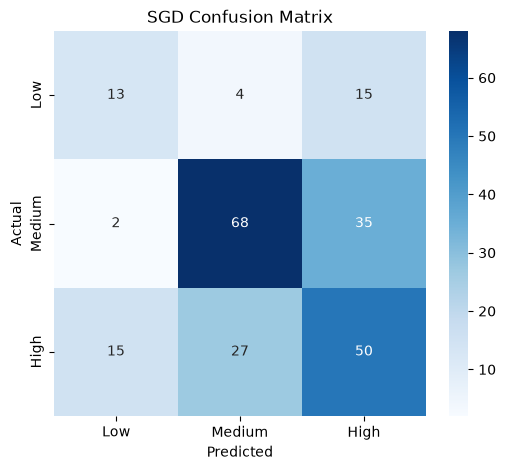

In [19]:
sgd_cm = confusion_matrix(y_test, sgd_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

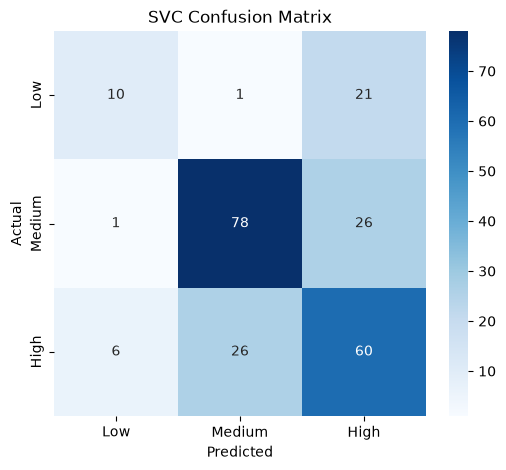

In [20]:
svc_cm = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
10,alcohol,0.133277
9,sulphates,0.128151
1,volatile acidity,0.104869
6,total sulfur dioxide,0.090002
7,density,0.080884
11,Id,0.080813
2,citric acid,0.070687
4,chlorides,0.067992
8,pH,0.064313
0,fixed acidity,0.062946


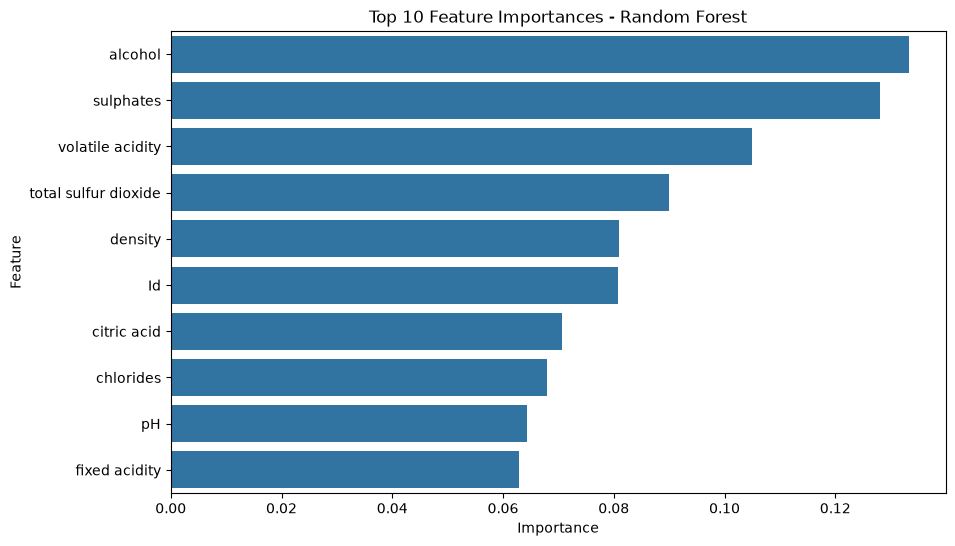

In [22]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        precision_score(y_test, sgd_pred, average="weighted", zero_division=0),
        precision_score(y_test, svc_pred, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, sgd_pred, average="weighted", zero_division=0),
        recall_score(y_test, svc_pred, average="weighted", zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, sgd_pred, average="weighted", zero_division=0),
        f1_score(y_test, svc_pred, average="weighted", zero_division=0)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.672,0.678,0.672,0.674
1,SGD,0.572,0.576,0.572,0.574
2,SVC,0.646,0.648,0.646,0.640


## Conclusion

Three classification models—Random Forest, SGD Classifier, and SVC—were trained to predict wine quality groups based on their physicochemical properties.

The models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices. Among the three models, **Random Forest achieved the best overall performance**, with an accuracy of **67.2%** and an F1-score of **67.4%**. SVC followed with an accuracy of **64.6%**, while SGD achieved **57.2%**.

Therefore, **Random Forest is the most suitable model for deployment among the models tested in this project**, as it provided the strongest overall predictive performance.

The analysis also showed that the wine quality classes were imbalanced, which can affect classification performance. Grouping the original quality scores into Low, Medium, and High categories made the classification problem more manageable.

Overall, this project demonstrated how exploratory data analysis, feature engineering, stratified train-test splitting, classification algorithms, and model evaluation can be combined to predict wine quality.
